<a href="https://colab.research.google.com/github/zakari90/-DataAnalysis/blob/main/car_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [86]:
path = "/content/drive/MyDrive/hsoub ai/car_sales_new.csv"
df = pd.read_csv(path)
df.head(2)

,car,price,body,mileage,engV,engType,registration,year,model,drive
0,Ford,15500.0,crossover,68,2.5,Gas,yes,2010,Kuga,full
1,Mercedes-Benz,20500.0,sedan,173,1.8,Gas,yes,2011,E-Class,rear


In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9576 entries, 0 to 9575
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   car           9576 non-null   object 
 1   price         9576 non-null   float64
 2   body          9576 non-null   object 
 3   mileage       9576 non-null   int64  
 4   engV          9142 non-null   float64
 5   engType       9576 non-null   object 
 6   registration  9576 non-null   object 
 7   year          9576 non-null   int64  
 8   model         9576 non-null   object 
 9   drive         9065 non-null   object 
dtypes: float64(2), int64(2), object(6)
memory usage: 748.3+ KB


In [88]:
df.isnull().sum()

,0
car,0
price,0
body,0
mileage,0
engV,434
engType,0
registration,0
year,0
model,0
drive,511


In [89]:
percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
percent

,0
drive,0.053363
engV,0.045322
price,0.000000
car,0.000000
mileage,0.000000
body,0.000000
engType,0.000000
registration,0.000000
year,0.000000
model,0.000000


In [90]:
df.describe()

,price,mileage,engV,year
count,9576.000000,9576.000000,9142.000000,9576.000000
mean,15633.317316,138.862364,2.646344,2006.605994
std,24106.523436,98.629754,5.927699,7.067924
min,0.000000,0.000000,0.100000,1953.000000
25%,4999.000000,70.000000,1.600000,2004.000000
50%,9200.000000,128.000000,2.000000,2008.000000
75%,16700.000000,194.000000,2.500000,2012.000000
max,547800.000000,999.000000,99.990000,2016.000000


In [91]:
print("How many values have price = 0? : ", df.price[df.price == 0].count())

How many values have price = 0? :  267


In [92]:
print("How many values have mileage = 0 : ", df.mileage[df.mileage == 0].count())

How many values have mileage = 0 :  348


In [93]:
df.columns = map(str.lower, df.columns)
df.dtypes

,0
car,object
price,float64
body,object
mileage,int64
engv,float64
engtype,object
registration,object
year,int64
model,object
drive,object


In [94]:
df.head()

,car,price,body,mileage,engv,engtype,registration,year,model,drive
0,Ford,15500.0,crossover,68,2.5,Gas,yes,2010,Kuga,full
1,Mercedes-Benz,20500.0,sedan,173,1.8,Gas,yes,2011,E-Class,rear
2,Mercedes-Benz,35000.0,other,135,5.5,Petrol,yes,2008,CL 550,rear
3,Mercedes-Benz,17800.0,van,162,1.8,Diesel,yes,2012,B 180,front
4,Mercedes-Benz,33000.0,vagon,91,NaN,Other,yes,2013,E-Class,NaN


In [95]:
df['drive'] = df['drive'].fillna("UnSpecified")
df.drive.unique()

array(['full', 'rear', 'front', 'UnSpecified'], dtype=object)

In [96]:
df['engv'].isna().sum()
# df['engv'].fillna((df['engv'].mean()), inplace=True)

np.int64(434)

In [97]:
df['price'] = df['price'].replace(0, df['price'].mean())

In [98]:
# mileage_avg = sum(df['mileage']) / len(df['mileage'])
mileage_avg  = df["mileage"].mean()
df['mileage_level'] = ["high mileage" if i > mileage_avg else "low mileage" for i in df['mileage']]
df.loc[0:10]
# mileage_avg


,car,price,body,mileage,engv,engtype,registration,year,model,drive,mileage_level
0,Ford,15500.000,crossover,68,2.5,Gas,yes,2010,Kuga,full,low mileage
1,Mercedes-Benz,20500.000,sedan,173,1.8,Gas,yes,2011,E-Class,rear,high mileage
2,Mercedes-Benz,35000.000,other,135,5.5,Petrol,yes,2008,CL 550,rear,low mileage
3,Mercedes-Benz,17800.000,van,162,1.8,Diesel,yes,2012,B 180,front,high mileage
4,Mercedes-Benz,33000.000,vagon,91,NaN,Other,yes,2013,E-Class,UnSpecified,low mileage
5,Nissan,16600.000,crossover,83,2.0,Petrol,yes,2013,X-Trail,full,low mileage
6,Honda,6500.000,sedan,199,2.0,Petrol,yes,2003,Accord,front,high mileage
7,Renault,10500.000,vagon,185,1.5,Diesel,yes,2011,Megane,front,high mileage
8,Mercedes-Benz,21500.000,sedan,146,1.8,Gas,yes,2012,E-Class,rear,high mileage
9,Mercedes-Benz,22700.000,sedan,125,2.2,Diesel,yes,2010,E-Class,rear,low mileage


In [99]:
df["mileage"].mean()

np.float64(138.8623642439432)

In [100]:
df.mileage[df.mileage == 0 ]

,mileage
10,0
17,0
20,0
21,0
24,0
...,...
9234,0
9268,0
9382,0
9483,0


<Axes: xlabel='year'>

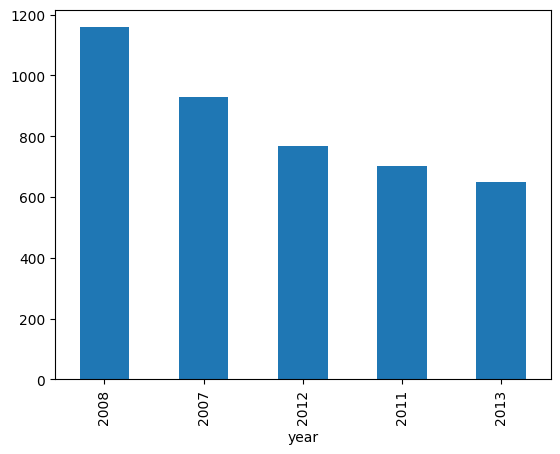

In [101]:
df["year"].value_counts().head().plot.bar()

<Axes: xlabel='body'>

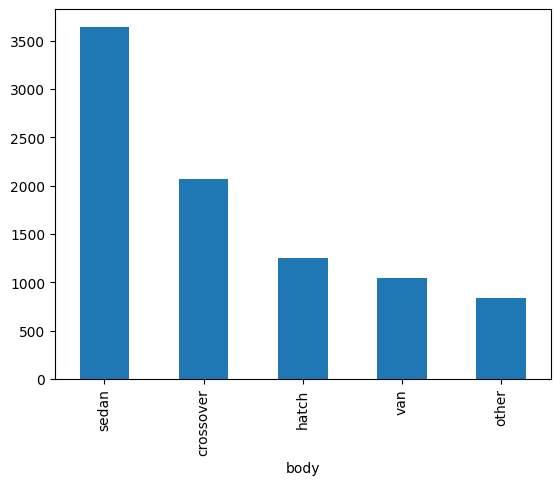

In [102]:
df["body"].value_counts().head().plot.bar()

In [103]:
usa = df.loc[df['car'] == 'Volkswagen']
usa['model']

,model
32,Passat B6
35,Passat B6
54,Passat B6
62,Passat B5
63,Passat B5
...,...
9557,T5 (Transporter) пасс.
9560,T5 (Transporter) пасс.
9564,T5 (Transporter) пасс.
9569,Tiguan


/tmp/ipykernel_14708/1661241471.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


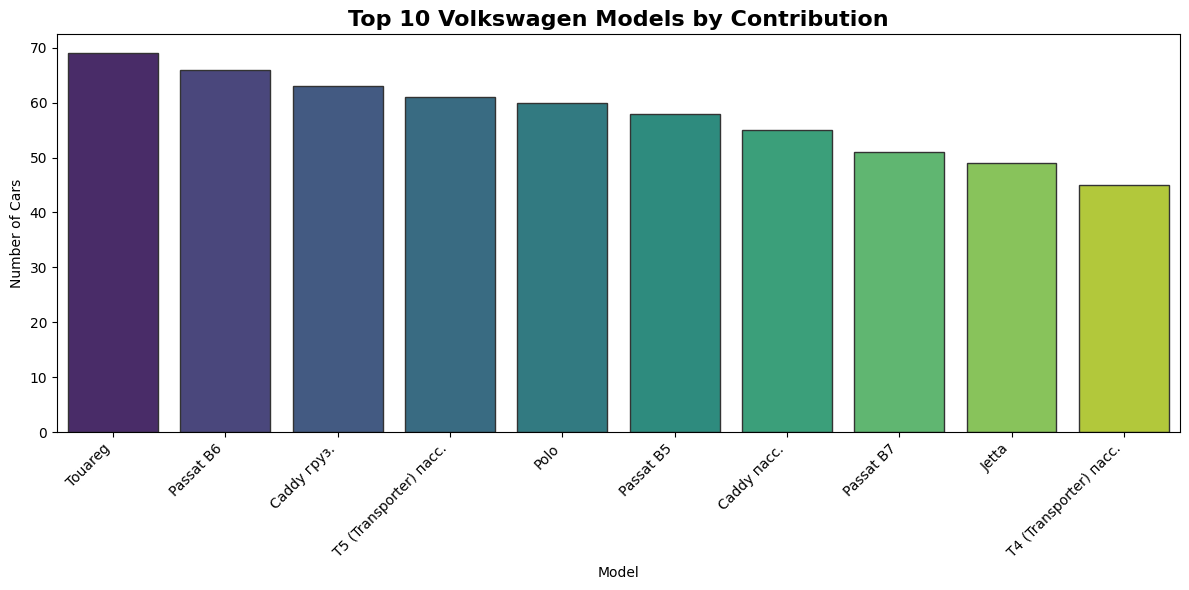

In [104]:
volkswagen_cars = df.loc[df['car'] == 'Volkswagen']
top_10_volkswagen_models = volkswagen_cars['model'].value_counts()[:10].to_frame()

plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_10_volkswagen_models.index, # Model names are in the index
    y=top_10_volkswagen_models['count'], # Counts are in the 'count' column
    palette="viridis",
    edgecolor=".2"
)
plt.title('Top 10 Volkswagen Models by Contribution', fontsize=16, fontweight="bold")
plt.xlabel('Model')
plt.ylabel('Number of Cars')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_14708/4003759752.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


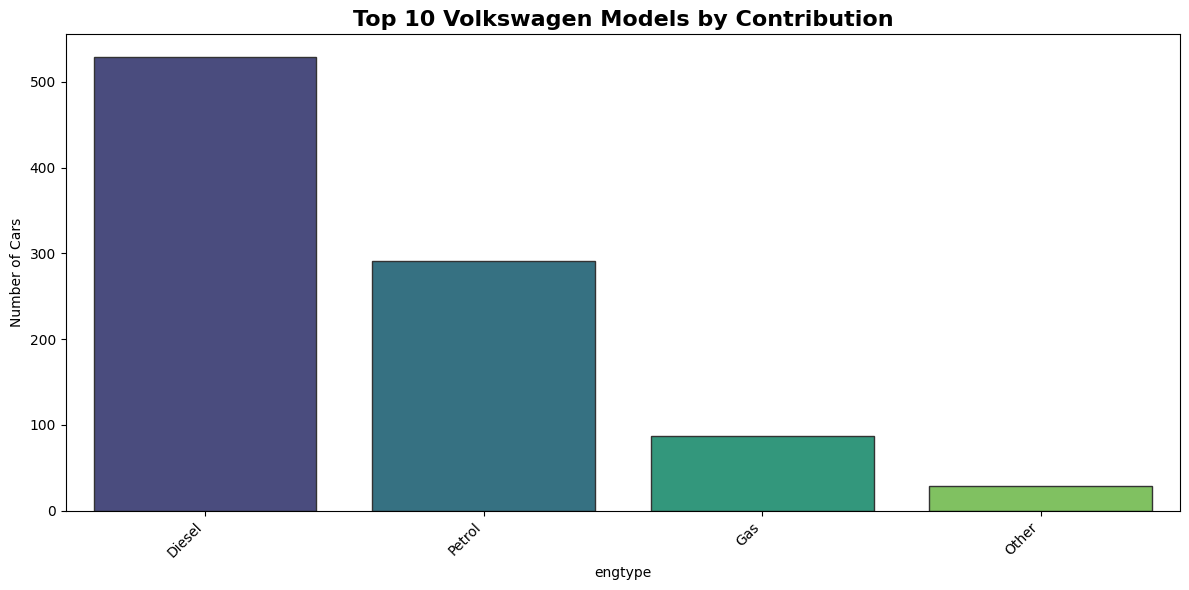

In [105]:
volkswagen_cars = df.loc[df['car'] == 'Volkswagen']
top_10_volkswagen_models = volkswagen_cars['engtype'].value_counts()[:10].to_frame()

plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_10_volkswagen_models.index,
    y=top_10_volkswagen_models['count'], # Counts are in the 'count' column
    palette="viridis",
    edgecolor=".2"
)
plt.title('Top 10 Volkswagen Models by Contribution', fontsize=16, fontweight="bold")
plt.xlabel('engtype')
plt.ylabel('Number of Cars')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_14708/4020141046.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  ct = pd.value_counts(df['engtype'].values, sort=False)


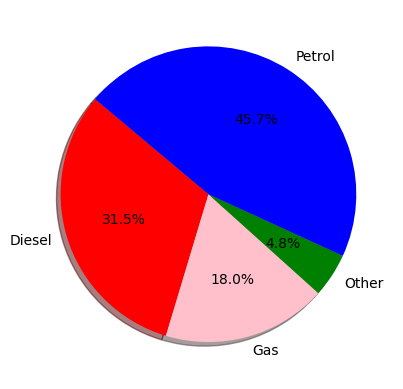

In [106]:
ct = pd.value_counts(df['engtype'].values, sort=False)
labels = df['engtype'].unique()
labels.sort()
sizes = ct
ct.sort_index(inplace=True)
colors = ['red', 'pink', 'green', 'blue']
plt.pie(sizes, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=140)

plt.show()

<Axes: xlabel='mileage', ylabel='price'>

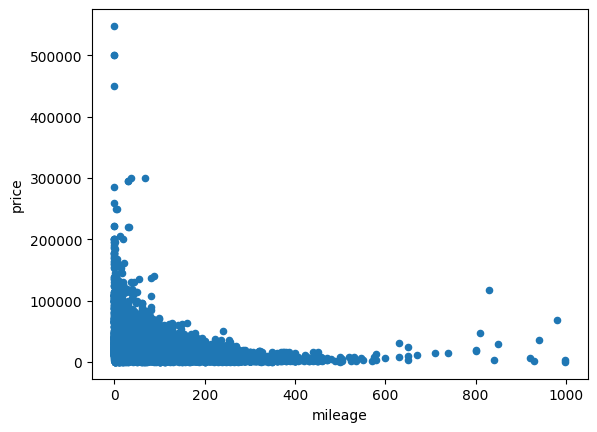

In [107]:
df.plot.scatter(x = 'mileage', y = 'price')

<Axes: xlabel='mileage', ylabel='price'>

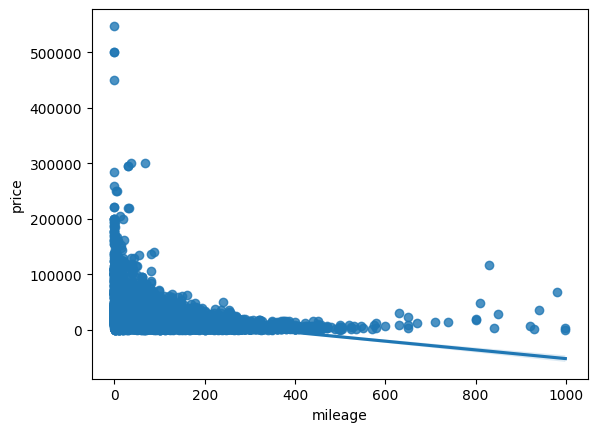

In [108]:
sns.regplot(x='mileage', y='price', data=df)

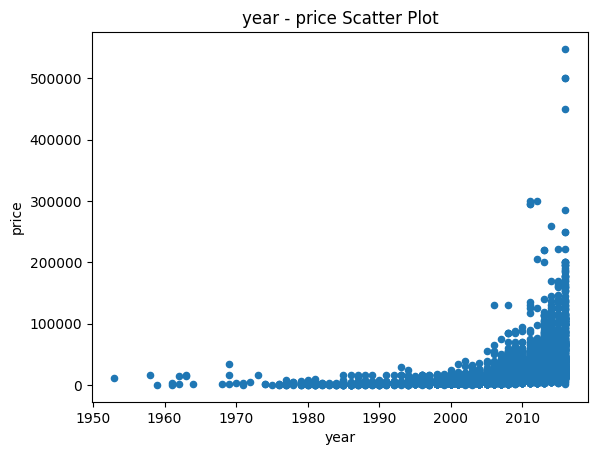

In [109]:
df.plot(kind = 'scatter', x='year', y = 'price')
plt.xlabel("year")
plt.ylabel("price")
plt.title("year - price Scatter Plot")
plt.show()

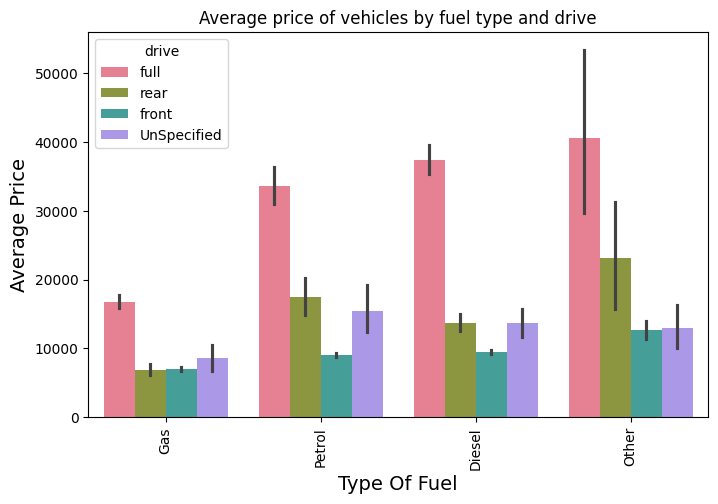

In [110]:
fig, ax = plt.subplots(figsize=(8,5))

sns.barplot(x="engtype", y="price", hue= "drive", palette="husl", data=df)
ax.set_title("Average price of vehicles by fuel type and drive",fontdict= {'size':12})
ax.xaxis.set_label_text("Type Of Fuel",fontdict= {'size':14})
ax.yaxis.set_label_text("Average Price",fontdict= {'size':14})
ticks = plt.setp(ax.get_xticklabels(),rotation=90)
plt.show()

In [129]:
df.duplicated().sum()
df["model"].duplicated().sum()

np.int64(8688)

In [135]:
print(df['car'].unique().size)
print(df['model'].unique().size)
print(df['engtype'].unique().size)
print(df['drive'].unique().size)

87
888
4
4


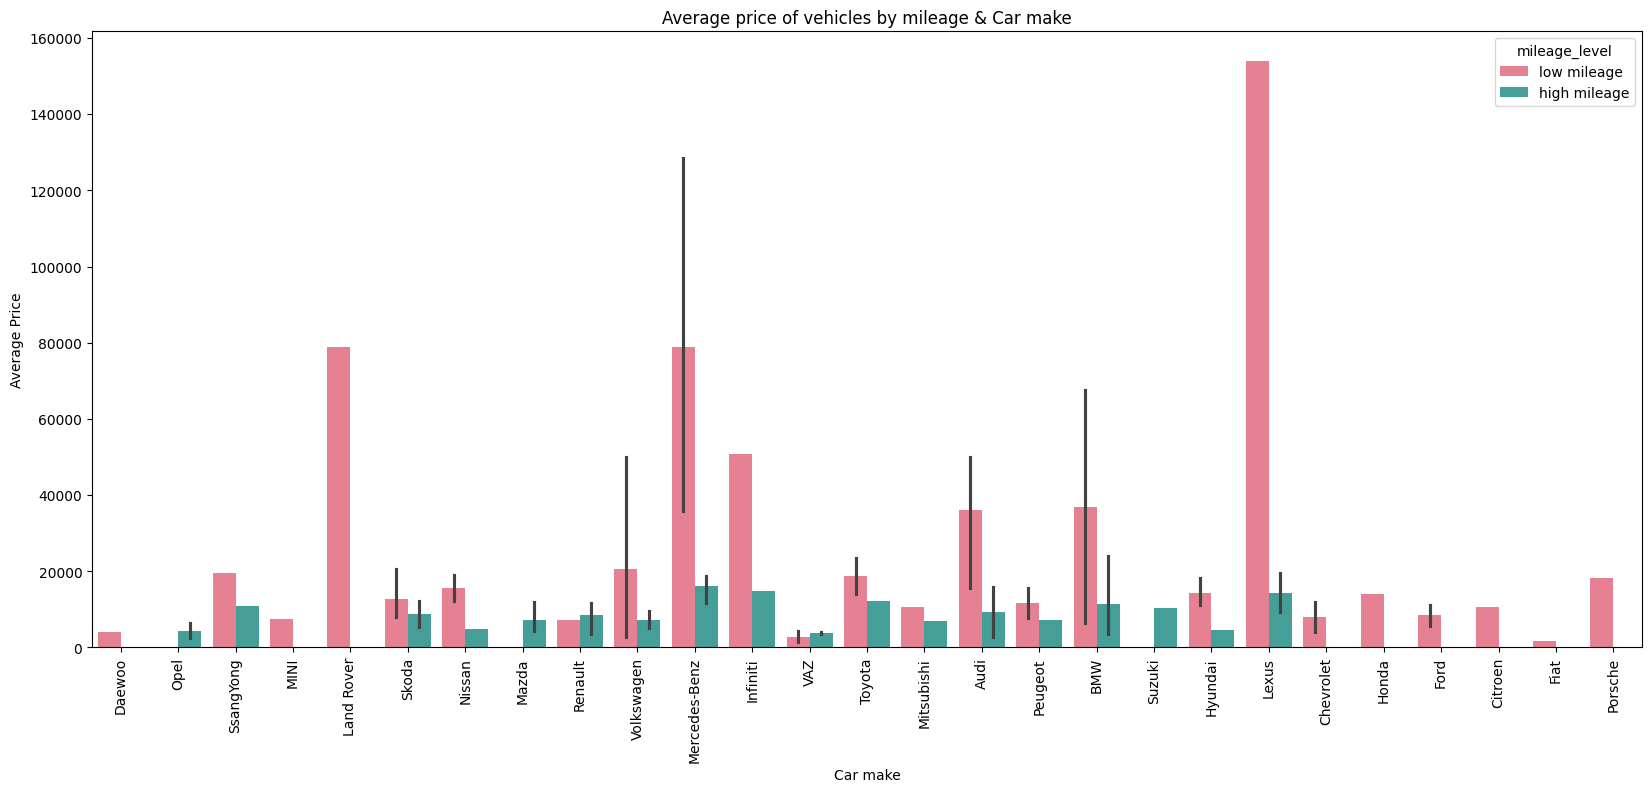

In [137]:
fig, ax = plt.subplots(figsize=(20,8))

Carsales_Sample = df.sample(80)
sns.barplot(x="car", y="price", hue= "mileage_level", palette="husl",data=Carsales_Sample)
ax.set_title("Average price of vehicles by mileage & Car make",fontdict= {'size':12})
ax.xaxis.set_label_text("Car make",fontdict= {'size':10})
ax.yaxis.set_label_text("Average Price",fontdict= {'size':10})
ticks = plt.setp(ax.get_xticklabels(),rotation=90)
plt.show()

In [112]:
corr = df.loc[:, df.dtypes != 'object'].corr(method='pearson')
corr

,price,mileage,engv,year
price,1.000000,-0.323532,0.053234,0.380048
mileage,-0.323532,1.000000,0.047070,-0.495599
engv,0.053234,0.047070,1.000000,-0.042251
year,0.380048,-0.495599,-0.042251,1.000000


<Axes: >

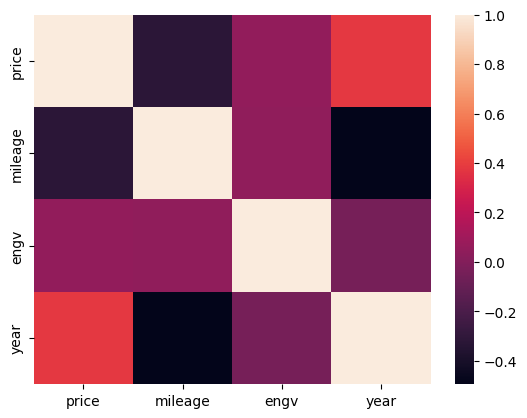

In [113]:
sns.heatmap(corr, xticklabels=corr.columns, yticklabels=corr.columns)